<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/lecture_5_Global_PCA_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook setup

Import the necessary modules

In [1]:
from skimage.io import imread  # pyright: ignore[reportMissingImports]
import numpy as np
from matplotlib import pyplot as plt
from scipy.fft import idct

Define the root folder for the project

In [2]:
ROOT_FOLDER = './data'

Useful function for plotting a 2D dictionary

In [3]:
def get_dictionary_img(D):
    M = D.shape[0]
    p = int(round(np.sqrt(M)))
    bound = 2
    img = np.ones((p*p+bound*(p-1), p*p+bound*(p-1)))
    for i in range(M):
        m = np.mod(i, p)
        n = int((i-m)/p)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Load the image and rescale it in $[0,1]$

In [ ]:
img = imread(f'{ROOT_FOLDER}/barbara.png') / \
    255  # /Lena512.png or /cameraman.png

imsz = img.shape

p = 8                                       # patch size
M = p ** 2                                  # no. of elements in the patch
# No. of overlapping patches
num_patches = (imsz[0] - p + 1) * (imsz[1] - p + 1)

Corrupt the image with white gaussian noise

In [5]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz) * sigma_noise

Compute the PSNR of the noisy input

In [6]:
psnr_noisy = 10 * np.log10(1/np.mean(np.square(noisy_img - img)))

Text(0.5, 1.0, 'Noisy image, PSNR = 22.10')

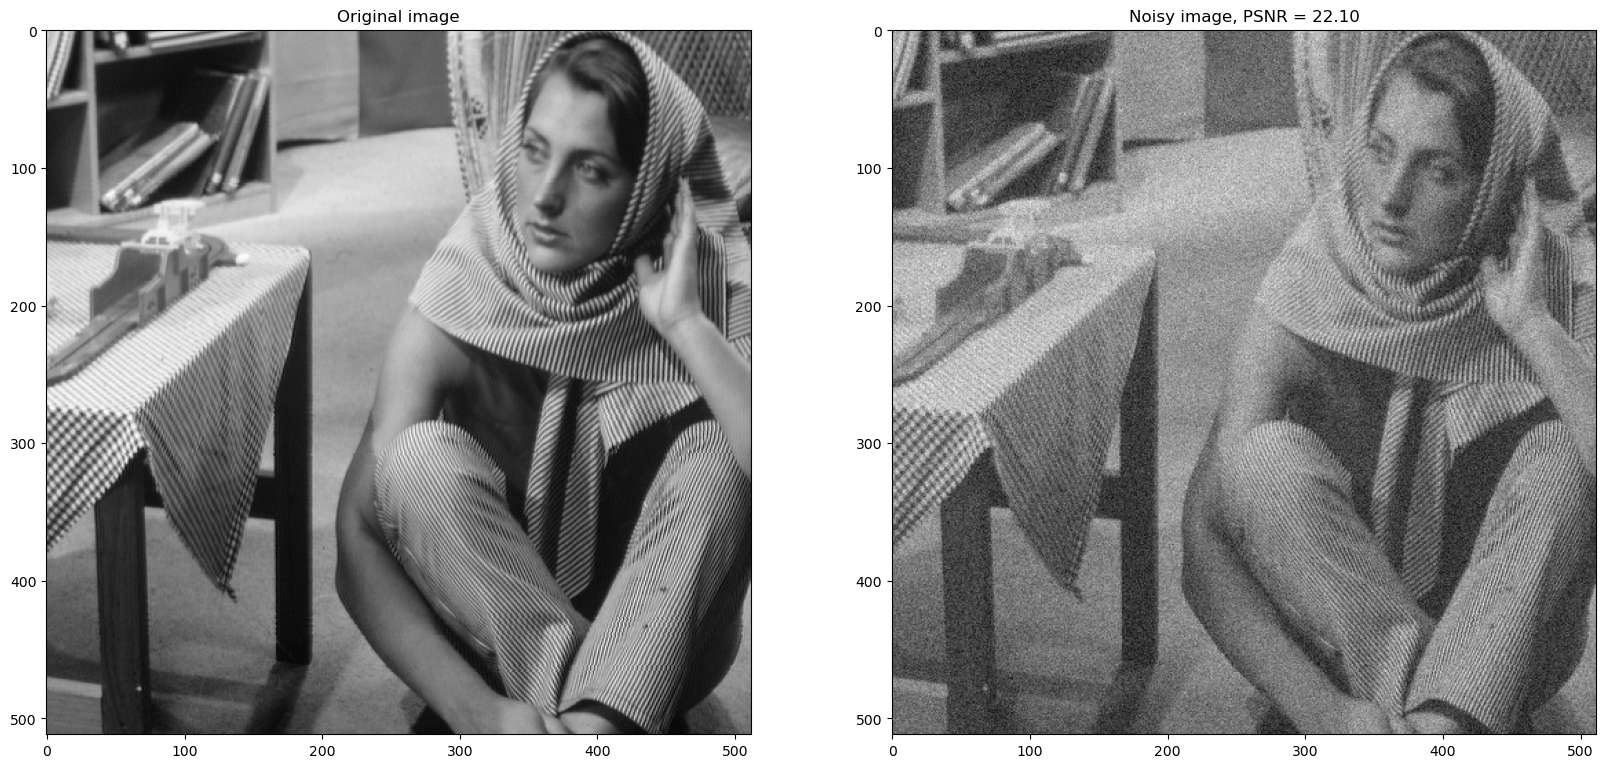

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

# Generate the Global PCA basis for this image

Set the parameters for denoising

In [8]:
# Set the threshold for Hard Thresholding
tau = 3 * sigma_noise
# tau = sigma_noise * np.sqrt(2 * np.log(M))    # Donoho threshold

Stack all the image patches in a large matrix $S$  
Each patch goes in a column of $S$

In [9]:
S = np.zeros((M, num_patches))

STEP = 1
cnt = 0

for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        S[:, cnt] = noisy_img[i:i + p, j:j + p].reshape(M)
        cnt += 1

Compute $\tilde S$ by zero centering $S$


In [10]:
avg_patch = S.mean(axis=0, keepdims=True)
Stilde = S - avg_patch

Compute the PCA transformation via SVD


In [11]:
U, Sigma, _ = np.linalg.svd(Stilde @ Stilde.T, full_matrices=False)

Generate the 2-D DCT basis

In [12]:
def idct2(x):
    return idct(idct(x.T, norm='ortho').T, norm='ortho')

In [13]:
D = np.zeros((M, M))
cnt = 0
for i in range(p):
    for j in range(p):
        # Construct the basis element E
        E = np.zeros((p, p))
        E[i, j] = 1.0
        D[:, cnt] = idct2(E).reshape(-1)  # Infer the dimension for reshaping
        cnt = cnt + 1

Show the learned PCA basis and compare these against DCT basis

(-0.5, 77.5, 77.5, -0.5)

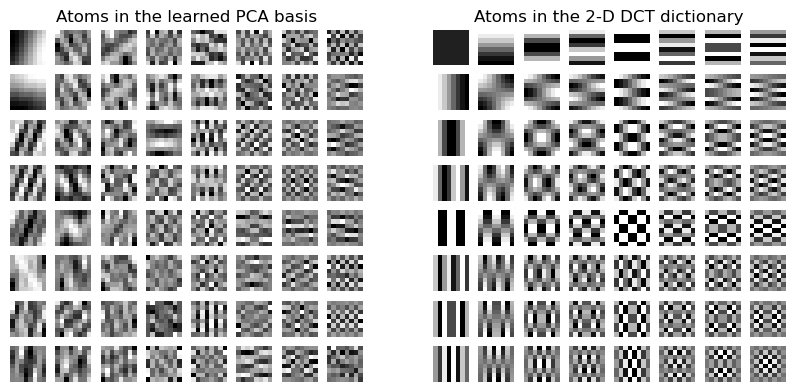

In [14]:
D_img = get_dictionary_img(D)
U_img = get_dictionary_img(U)

fig, ax = plt.subplots(1, 2, figsize=(10, 10))

ax[0].imshow(U_img, cmap='gray')
ax[0].set_title('Atoms in the learned PCA basis')
ax[0].axis('off')

ax[1].imshow(D_img, cmap='gray')
ax[1].set_title('Atoms in the 2-D DCT dictionary')
ax[1].axis('off')

# Patch-based denoising
Initialize the variables

In [15]:
# Initialize the estimated image
img_hat = np.zeros_like(img)

# Initialize the weight matrix
weights = np.zeros_like(img)

In [16]:
cnt = 0
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # Extrach the patch
        s = np.reshape(noisy_img[i:i + p, j:j + p], M)

        # Subtract avg_patch
        s = s - avg_patch[:, cnt]

        # Compute the representation w.r.t. the PCA basis
        x_hat = U.T @ s

        # Perform hard thresholding
        x_hat[1:][np.abs(x_hat[1:]) < tau] = 0.0

        # Perform the reconstruction
        y_hat = U @ x_hat

        # Add avg_patch back
        y_hat = y_hat + avg_patch[:, cnt]

        # Compute the weight for the reconstructed patch
        w = 1

        # Accumulate, by summation, the denoised patch into the denoised image
        # using the computed weights
        img_hat[i:i + p, j:j + p] += w * y_hat.reshape(p, p)

        # Store the weight of the current patch in the weight matrix
        weights[i:i + p, j:j + p] += w
        cnt += 1

# Normalize the estimated image with the computed weights
img_hat = img_hat / weights

Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image \nPSNR = 29.50')

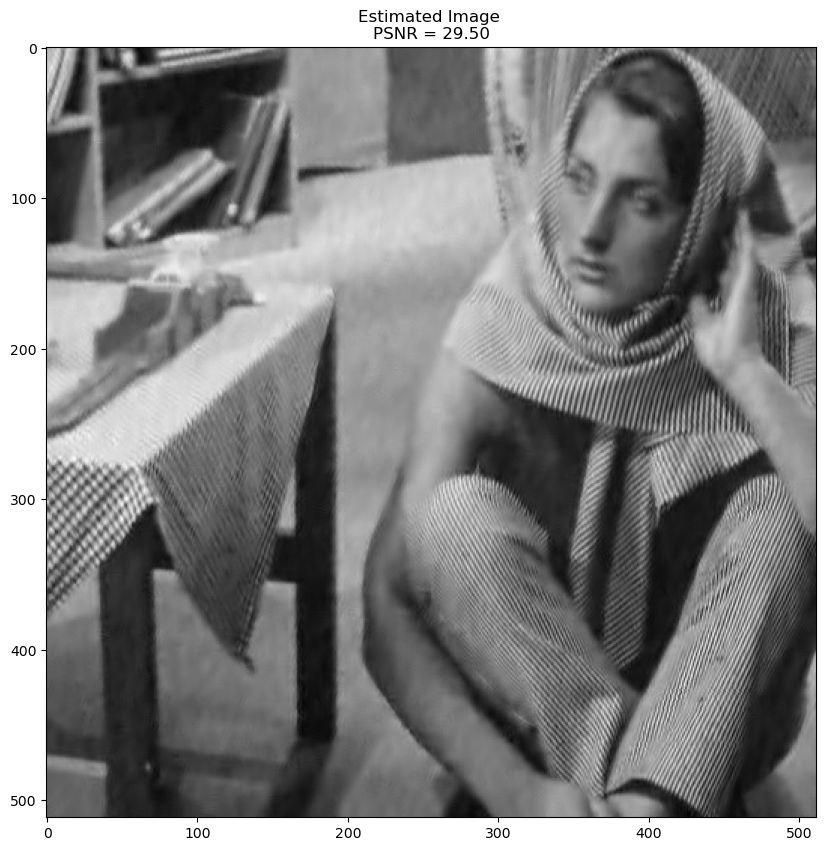

In [17]:
psnr_hat = 10 * np.log10(1/np.mean(np.square(img_hat - img)))
plt.figure(figsize=(10, 10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image \nPSNR = {psnr_hat:.2f}')

# Variant: Projection over the first $K$ Principal Components

Select the principal $K$ components selected via Linear Thresholding with 
a user-defined threshold

In [18]:
threshold = 0.8
cum_sigma = np.cumsum(Sigma / np.sum(Sigma))
k = np.searchsorted(cum_sigma, threshold)
U_k = U[:, :k + 1] if k < len(cum_sigma) - 1 else U
print(f'Selected components: {k + 1}/{M}')

Selected components: 37/64


Execute the usual patch-based denoising algorithm

In [19]:
# Initialize the estimated image
img_hat = np.zeros_like(img)

# Initialize the weight matrix
weights = np.zeros_like(img)

cnt = 0
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # Extrach the patch
        s = np.reshape(noisy_img[i:i + p, j:j + p], M)

        # Subtract avg_patch
        s -= avg_patch[:, cnt]

        # Compute the representation w.r.t. the PCA basis
        x_hat = U_k.T @ s

        # Perform hard thresholding
        x_hat[1:][np.abs(x_hat[1:]) < tau] = 0.0

        # Perform the reconstruction
        y_hat = U_k @ x_hat

        # Add avg_patch back
        y_hat += avg_patch[:, cnt]

        # Compute the weight for the reconstructed patch
        w = 1

        # Accumulate, by summation, the denoised patch into the denoised image
        # using the computed weights
        img_hat[i:i + p, j:j + p] += w * y_hat.reshape(p, p)

        # Store the weight of the current patch in the weight matrix
        weights[i:i + p, j:j + p] += w
        cnt += 1

# Normalize the estimated image with the computed weights
img_hat = img_hat / weights

Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image \nPSNR = 29.46')

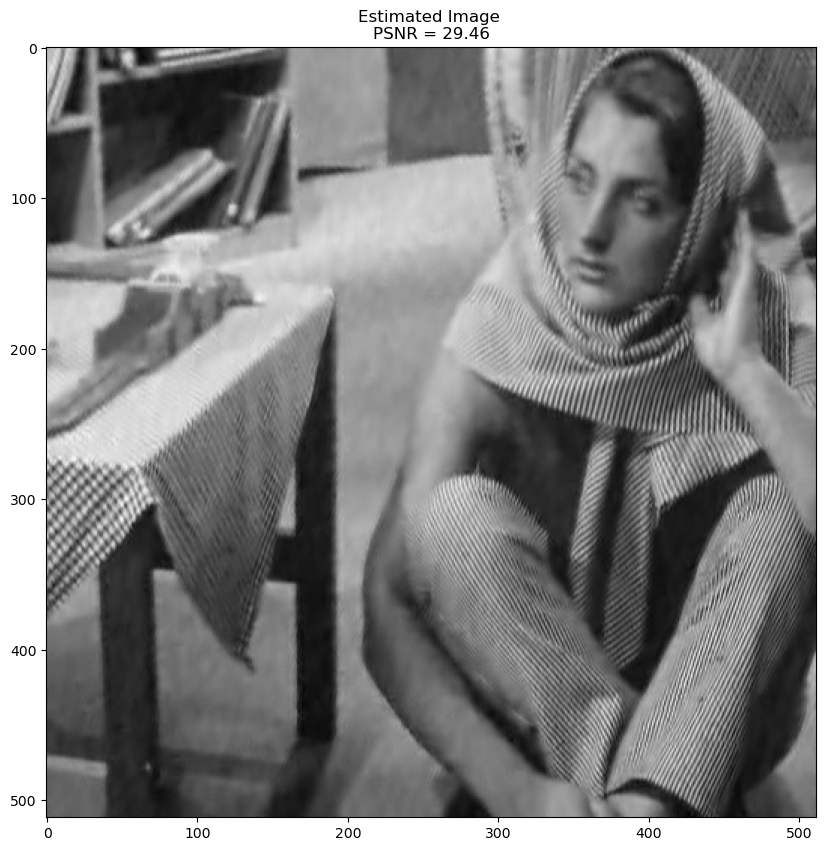

In [20]:
psnr_hat = 10 * np.log10(1/np.mean(np.square(img_hat - img)))
plt.figure(figsize=(10, 10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image \nPSNR = {psnr_hat:.2f}')

The global-PCA denoising algorithm uses linear operations when 
projecting onto the full basis $U$ or onto the first $K$ principal components of $U$.
However, the overall denoising map is not linear, as hard thresholding depends 
on the input coefficients.

By projecting and enforcing sparsity with respect to the basis $U$, the 
performance of the global-PCA denoising algorithm are better than the case when
only the first $K$ principal components are used, as it is confirmed by a generally
higher PSNR in the first variant.  
Of course, it appears better to consider all 
the atoms in $U$ as relevant for modelling the patches of the image.

Such performance difference can be explained by noticing that, in the second 
variant, the information (in the form of variability of the training set $\tilde S$) associated with the last $M - K  + 1$ principal 
components is not retained in the analysis and synthesis stages as they are considered as noise.

For instance, consider the computation of the representation $\mathbf{x} \in \mathbb{R}^{M}$ of the (flattened) 
patch $\mathbf{s} = [s_i] \in \mathbb{R}^{M}$ w.r.t the PCA-learned basis 
$U = [u_{ij}] \in \mathbb{R}^{M \times M}$ and w.r.t. the reduced basis $U_{K} \in \mathbb{R}^{M \times K}$ (with $K < M$)

$$
\mathbf{x} = U^{T}\mathbf{s} = \sum_{i,j = 1}^{M} u_{ij}^{T}s_i = \sum_{i = 1}^{M} \left(\sum_{j = 1}^{K} u_{ij}^{T}s_i + \sum_{j = K + 1}^{M} u_{ij}^{T}s_i \right) = \sum_{i = 1}^{M}\sum_{j = 1}^{K} u_{ij}^{T}s_i + \sum_{i = 1}^{M}\sum_{j = K + 1}^{M} u_{ij}^{T}s_i = U_{K}^{T}\mathbf{s} + \sum_{i = 1}^{M}\sum_{j = K + 1}^{M} u_{ij}^{T}s_i
$$

# Generate the Local PCA basis for this image

Implement a function to estimate the local PCA basis within an image region

In [21]:
def local_pca_basis(img, region_size=32, start_coord=(0, 0), threshold=None):

    x_start, y_start = start_coord
    imsz = img.shape

    if len(imsz) != 2:
        raise ValueError('Invalid image provided!')

    if region_size <= 0:
        raise ValueError('Ilegal value for region_size!')

    if not (0 <= x_start < imsz[0]):
        raise ValueError('x_start must be between the image boundaries!')

    if not (0 <= y_start < imsz[1]):
        raise ValueError('y_start must be between the image boundaries')

    if (x_start + region_size > imsz[0] or y_start + region_size > imsz[1]):
        raise ValueError('The selected image region does not fall inside '
                         'the image boundaries')

    if threshold is not None and not (0 < threshold <= 1.0):
        raise ValueError('Illegal value for threshold!')

    reg = img[x_start:x_start + region_size, y_start: y_start + region_size]
    rgsz = reg.shape

    p = 8
    M = p ** 2
    num_patches = (rgsz[0] - p + 1) * (rgsz[1] - p + 1)
    STEP = 1
    cnt = 0

    S = np.zeros((M, num_patches))

    for i in range(0, rgsz[0] - p + 1, STEP):
        for j in range(0, rgsz[1] - p + 1, STEP):
            S[:, cnt] = reg[i:i + p, j:j + p].reshape(M)
            cnt += 1

    avg_patch = S.mean(axis=0, keepdims=True)
    s_tilde = S - avg_patch

    U, sigma, _ = np.linalg.svd(s_tilde @ s_tilde.T, full_matrices=False)

    if threshold is not None:
        cum_sigma = np.cumsum(sigma / np.sum(sigma))
        k = np.searchsorted(cum_sigma, threshold)
        return U[:, :k + 1] if k < len(cum_sigma) - 1 else U

    return U

Load the image `barbara.png` and normalize to $[0,1]$, then corrupt it with white
gaussian noise

In [22]:
img = imread(f'{ROOT_FOLDER}/barbara.png') / 255
imsz = img.shape
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz) * sigma_noise

Text(0.5, 1.0, 'Noisy image, PSNR = 22.13')

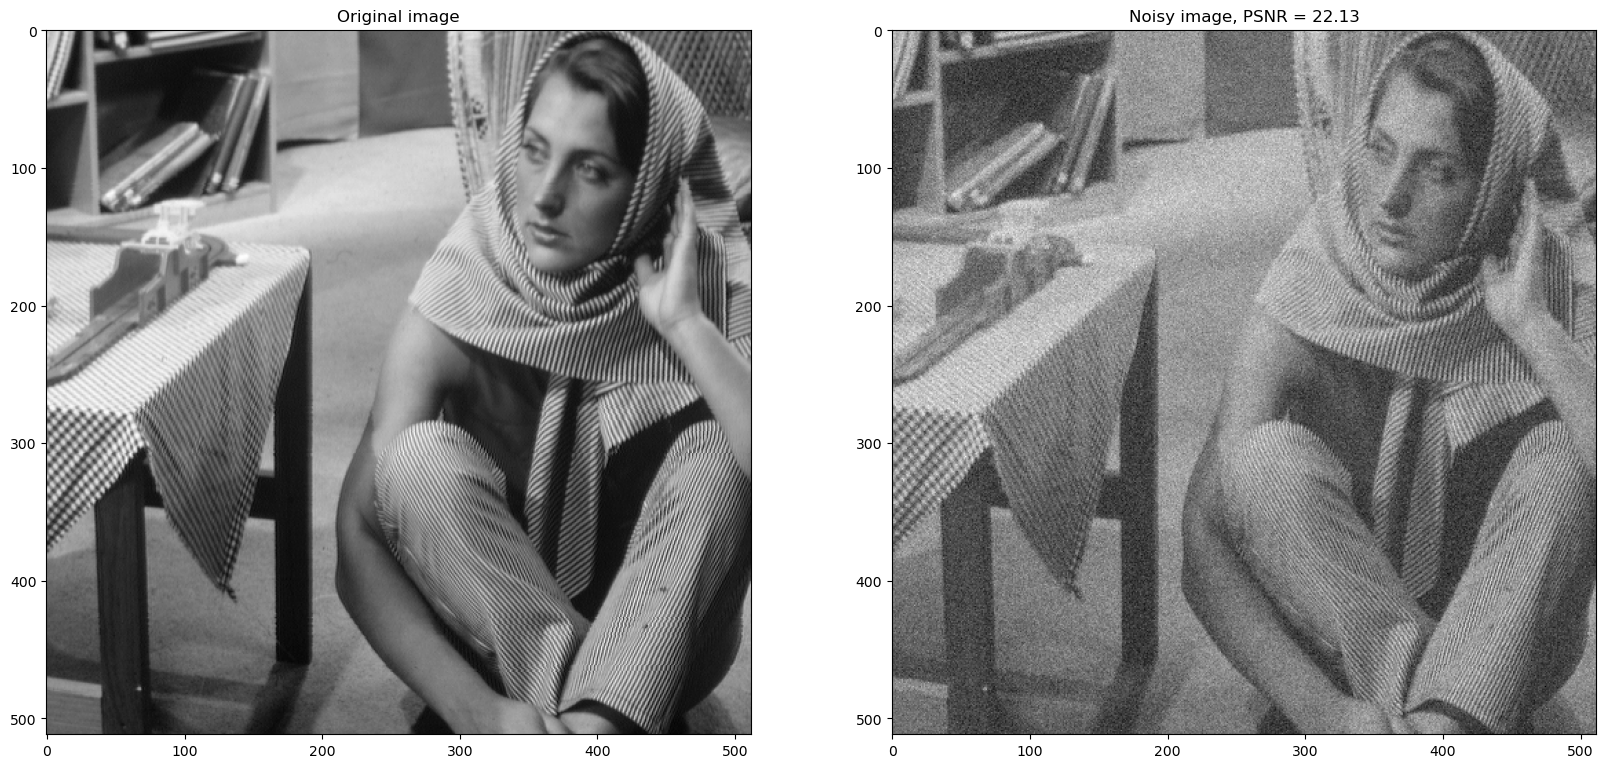

In [23]:
psnr_noisy = 10 * np.log10(1/np.mean(np.square(noisy_img - img)))

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

(-0.5, 77.5, 77.5, -0.5)

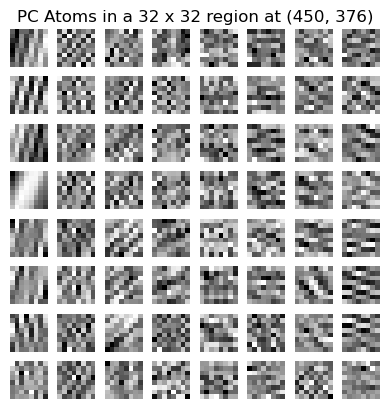

In [24]:
region_size = 32
start_coord = (450, 376)

U = local_pca_basis(noisy_img, region_size, start_coord)
U_img = get_dictionary_img(U)

plt.figure()
plt.imshow(U_img, cmap='gray')
plt.title(f'PC Atoms in a {region_size} x {region_size} '
          f'region at {start_coord}')
plt.axis('off')

Implement denoising by local-PCA basis using non-overlapping tiles  
For convenience, we've reported all the parameters for the denoising algorithm

In [25]:
# Generate a collection of basis

threshold = 0.8
tile_rows = range(0, imsz[0] - region_size + 1, region_size)
tile_cols = range(0, imsz[1] - region_size + 1, region_size)

basis_bank = []
for i in tile_rows:
    row_bases = []  # Store the learned basis in a 2-D grid structure
    for j in tile_cols:
        row_bases.append(local_pca_basis(
            noisy_img, region_size, (i, j), threshold))
    basis_bank.append(row_bases)

# Denoise by selecting the right basis in each pixel depending on its location

p = 8
M = p ** 2
tau = 3 * sigma_noise
STEP = 1

img_hat = np.zeros_like(noisy_img)
weights = np.zeros_like(noisy_img)

for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        s = np.reshape(noisy_img[i:i + p, j:j + p], M)
        avg_patch = s.mean()
        s = s - avg_patch

        ti = min(i // region_size, len(tile_rows) - 1)
        tj = min(j // region_size, len(tile_cols) - 1)
        U_k = basis_bank[ti][tj]

        x_hat = U_k.T @ s
        x_hat[1:][np.abs(x_hat[1:]) < tau] = 0.0
        y_hat = U_k @ x_hat
        y_hat += avg_patch

        w = 1
        img_hat[i:i + p, j:j + p] += w * y_hat.reshape(p, p)
        weights[i:i + p, j:j + p] += w

img_hat = img_hat / weights

Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image \nPSNR = 30.70')

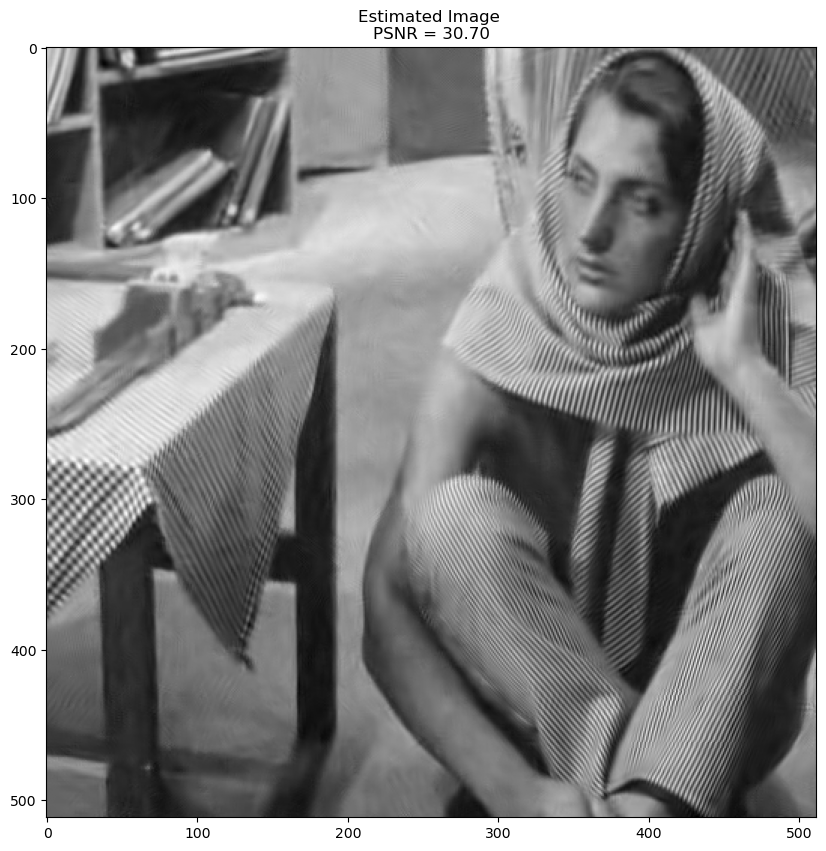

In [26]:
psnr_hat = 10 * np.log10(1/np.mean(np.square(img_hat - img)))
plt.figure(figsize=(10, 10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image \nPSNR = {psnr_hat:.2f}')

Implement denoising by local-PCA basis defining overlapping regions tiles  
The step of the sliding windows, represented by the variable `delta` in the code, 
was choosen accordingly to the suggestions provided in [[1]](#1)

In [27]:
delta = (region_size - 1) // 2
tile_rows = range(0, imsz[0] - region_size + 1, delta)
tile_cols = range(0, imsz[1] - region_size + 1, delta)

STEP = 1
p = 8
M = p ** 2
tau = 3 * sigma_noise

img_hat = np.zeros_like(noisy_img)
weights = np.zeros_like(noisy_img)

for i in tile_rows:
    for j in tile_cols:
        U_k = local_pca_basis(noisy_img, region_size, (i, j), threshold)

        x_start, y_start = (i, j)
        reg = noisy_img[x_start:x_start + region_size,
                        y_start: y_start + region_size]

        reg_hat = np.zeros_like(reg)
        weights_reg = np.zeros_like(reg)

        for k in range(0, region_size - p + 1, STEP):
            for l in range(0, region_size - p + 1, STEP):
                s = np.reshape(reg[k:k + p, l:l + p], M)
                avg_patch = s.mean()
                s -= avg_patch
                x_hat = U_k.T @ s
                x_hat[1:][np.abs(x_hat[1:]) < tau] = 0.0
                y_hat = U_k @ x_hat
                y_hat += avg_patch

                reg_hat[k:k + p, l:l + p] += y_hat.reshape(p, p)
                weights_reg[k:k + p, l:l + p] += 1

        reg_hat = reg_hat / weights_reg

        img_hat[x_start:x_start + region_size,
                y_start: y_start + region_size] += reg_hat
        weights[x_start:x_start + region_size,
                y_start: y_start + region_size] += 1

img_hat = img_hat / weights

Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image \nPSNR = 31.06')

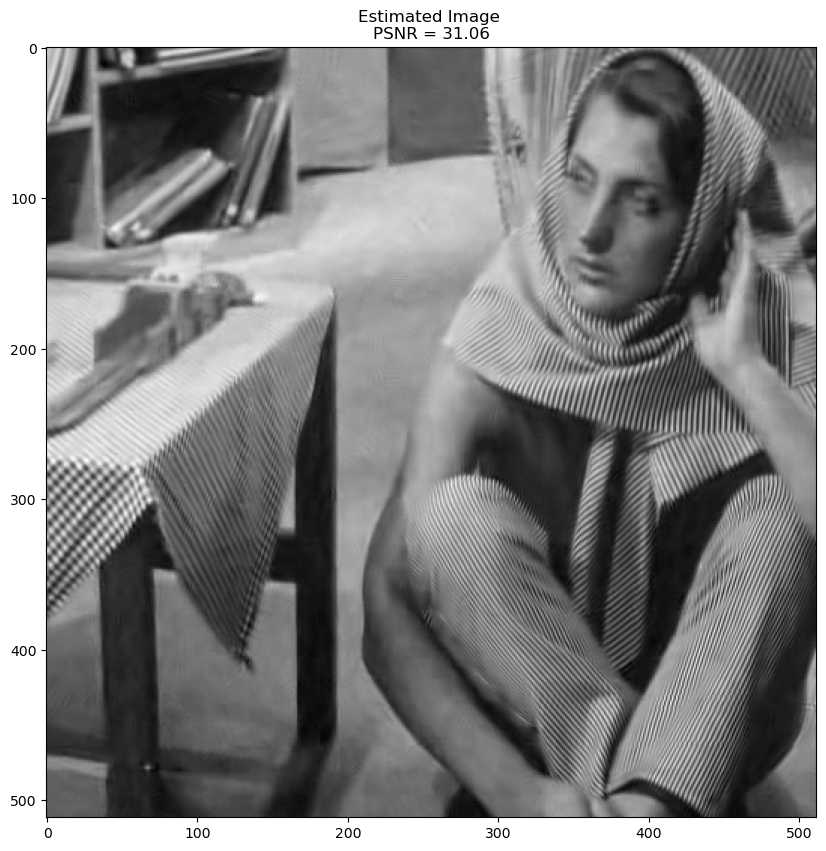

In [28]:
psnr_hat = 10 * np.log10(1/np.mean(np.square(img_hat - img)))
plt.figure(figsize=(10, 10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image \nPSNR = {psnr_hat:.2f}')

# References

<a id="1">[1]</a>
Charles-Alban Deledalle, J. Salmon, and A. S. Dalalyan, “Image denoising with 
patch based PCA: local versus global,” HAL (Le Centre pour la Communication 
Scientifique Directe), Jan. 2011